In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import time
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/K42_Lê Anh Tuấn _ Statistic & ML/churn_prediction.xlsx")
print(df.shape)
df.head(5)

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,229.53
1,52942,0,13.0,Computer,1,9.0,Cash on Delivery,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,NaN,9.0,234.38
2,52972,0,16.0,Mobile Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07
3,53125,0,5.0,Mobile Phone,1,16.0,Debit Card,Male,3.0,4,Fashion,4,Married,3,0,26.0,2.0,2.0,9.0,231.48
4,53367,0,9.0,Mobile Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165.14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [ ]:
missing_rows_percentage = df.isna().sum() / len(df) * 100

print (f"Tỉ lệ số dòng có missing values : \n{missing_rows_percentage}")

Tỉ lệ số dòng có missing values : 
CustomerID                     0.000000
Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64


In [ ]:
cols_with_na = missing_rows_percentage[missing_rows_percentage > 0].index
num_cols_na = df[cols_with_na].select_dtypes(include=['number']).columns
for col in num_cols_na:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_cols = df.select_dtypes(include=['float','int64']).columns
numeric_cols

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [ ]:
numerical_cols_list = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols_list.remove('CustomerID')
numerical_cols_list.remove('Churn')

original_shape = df.shape
print(f"Original shape of the DataFrame: {original_shape}")


for col in numerical_cols_list:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

new_shape = df.shape
print(f"New shape of the DataFrame after outlier removal: {new_shape}")
print(f"Number of rows removed: {original_shape[0] - new_shape[0]}")

Original shape of the DataFrame: (5630, 20)
New shape of the DataFrame after outlier removal: (3542, 20)
Number of rows removed: 2088


In [ ]:
display(df.describe())

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000
mean,52756.937888,0.194241,8.445793,1.649915,15.449746,2.931395,3.725579,3.075099,4.237154,0.288820,15.636364,1.094015,1.661773,3.163749,159.006121
std,1635.573917,0.395671,7.627798,0.912107,7.822706,0.697826,0.798414,1.370610,2.570925,0.453278,3.508156,0.791385,0.625362,2.428359,27.985020
min,50001.000000,0.000000,0.000000,1.000000,5.000000,1.000000,2.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,110.090000
25%,51333.250000,0.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,1.000000,140.140000
50%,52720.500000,0.000000,8.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,153.335000
75%,54170.500000,0.000000,12.000000,3.000000,19.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,2.000000,4.000000,174.360000
max,55630.000000,1.000000,31.000000,3.000000,36.000000,4.000000,5.000000,5.000000,11.000000,1.000000,25.000000,3.000000,3.000000,9.000000,241.310000


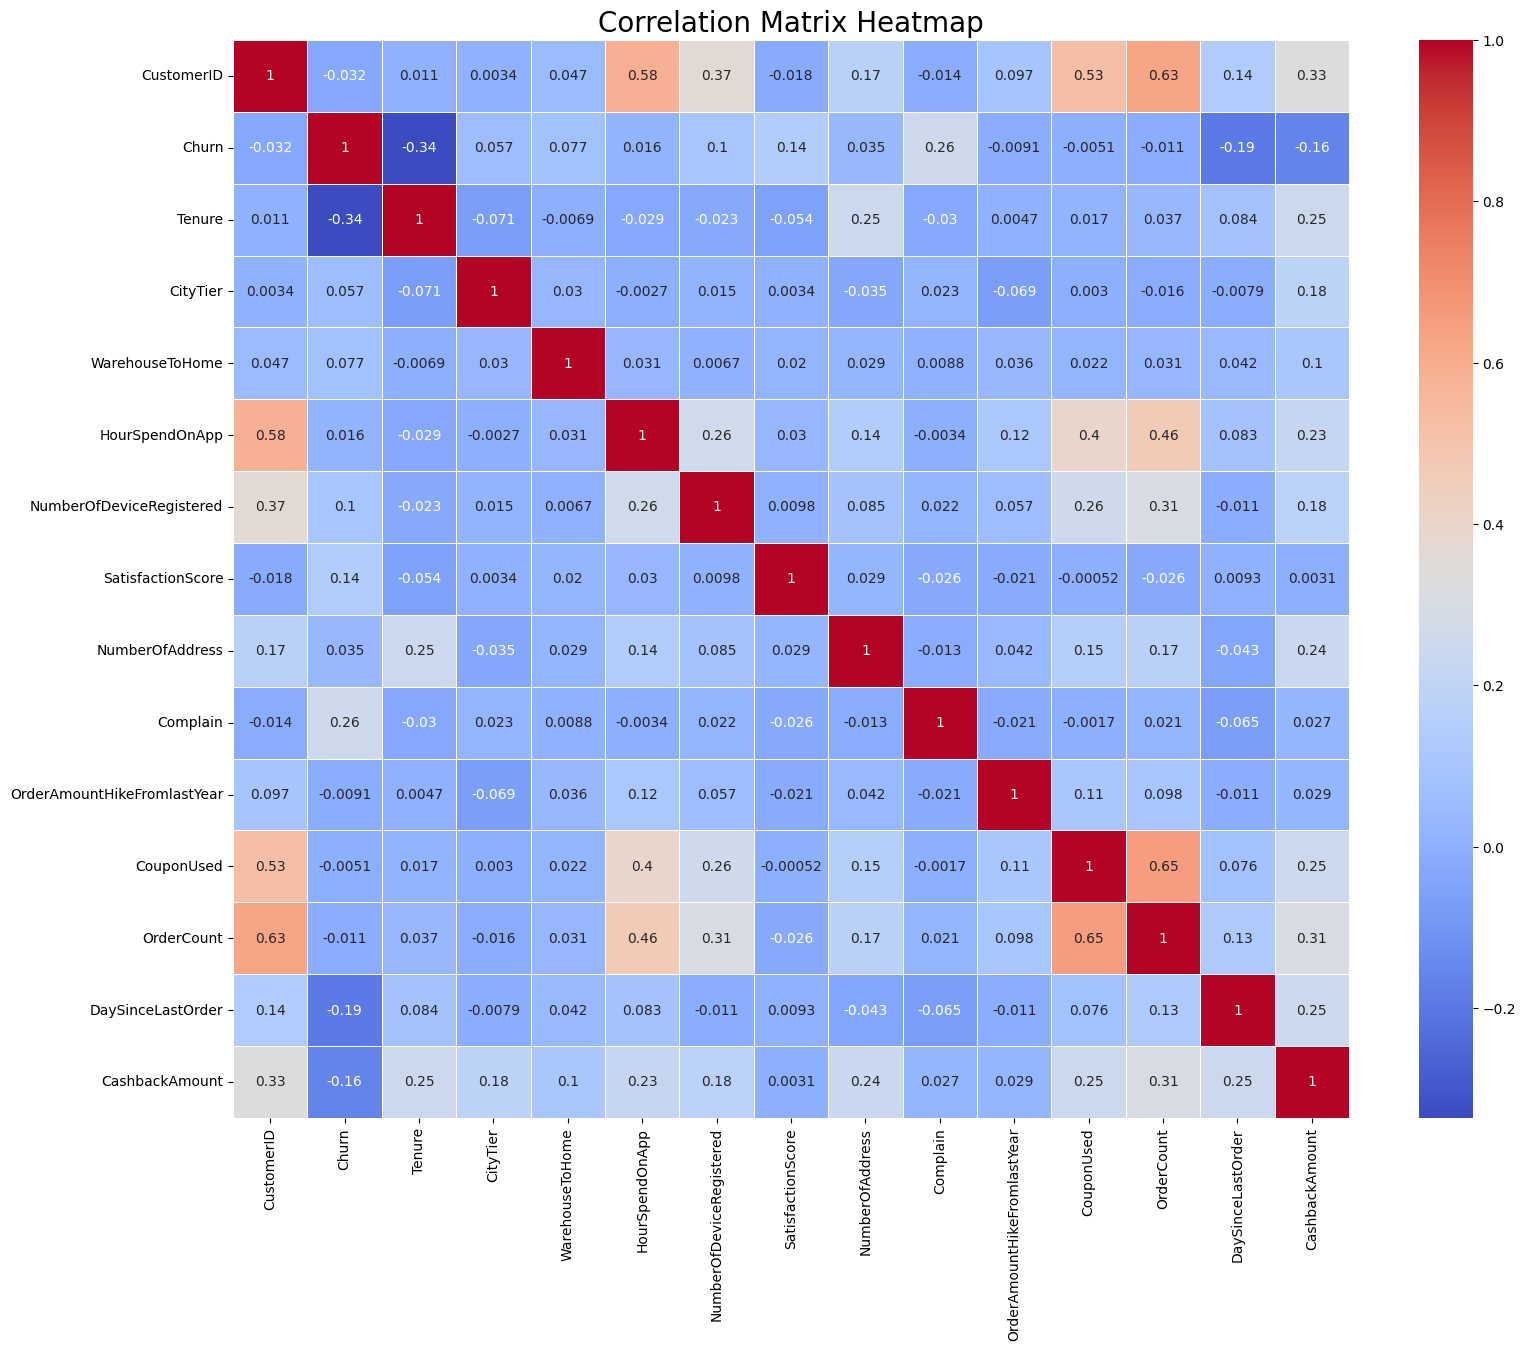

In [ ]:
plt.figure(figsize=(18, 14))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap', fontsize=20)
plt.show()

## 1. EDA: Phân tích hành vi của người dùng đã rời bỏ và Đề xuất giảm churn

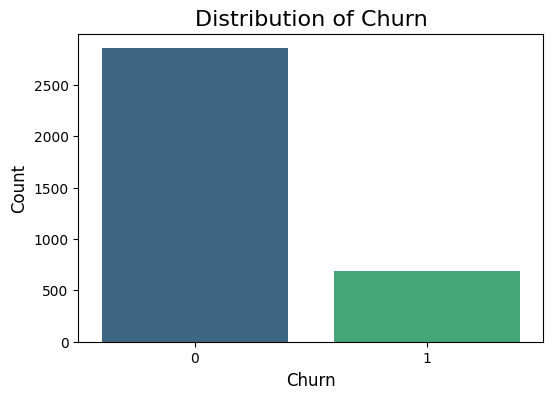

In [ ]:
# Visualize Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn', fontsize=16)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

## 2. Feature Engineering


In [ ]:
cate_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cate_cols:
    print(f"{col}:{df[col].unique()}")

PreferredLoginDevice:['Mobile Phone' 'Computer']
PreferredPaymentMode:['Debit Card' 'Credit Card' 'UPI' 'Cash on Delivery' 'E wallet']
Gender:['Male' 'Female']
PreferedOrderCat:['Fashion' 'Laptop & Accessory' 'Mobile Phone' 'Grocery']
MaritalStatus:['Married' 'Divorced' 'Single']


In [ ]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace(['COD', 'Cash on Delivery'], 'Cash on Delivery')
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('CC', 'Credit Card')
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')


In [ ]:
cat_cols_to_encode = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

# Thực hiện One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

print("Kích thước tập dữ liệu sau khi One-Hot Encoding:", df_encoded.shape)
display(df_encoded.head(5))

Kích thước tập dữ liệu sau khi One-Hot Encoding: (3542, 26)


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,MaritalStatus_Married,MaritalStatus_Single
36,50310,0,4.0,1,15.0,2.0,3,4,2,0,...,False,True,False,False,True,False,False,False,True,False
37,50552,0,8.0,1,27.0,2.0,3,2,2,1,...,False,True,False,False,False,False,True,False,False,False
38,50729,0,0.0,1,14.0,2.0,3,5,2,0,...,False,True,False,False,True,False,False,True,False,True
40,50768,1,9.0,1,16.0,3.0,4,4,2,1,...,True,False,False,False,False,False,False,True,False,True
41,50947,0,22.0,1,9.0,2.0,4,5,5,0,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Vì 10% là một nửa của 20%, ta dùng test_size=0.5
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Số lượng dữ liệu tập Train : {len(X_train)}")
print(f"Số lượng dữ liệu tập Validate : {len(X_val)}")
print(f"Số lượng dữ liệu tập Test : {len(X_test)}")

Số lượng dữ liệu tập Train : 2833
Số lượng dữ liệu tập Validate : 354
Số lượng dữ liệu tập Test : 355


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

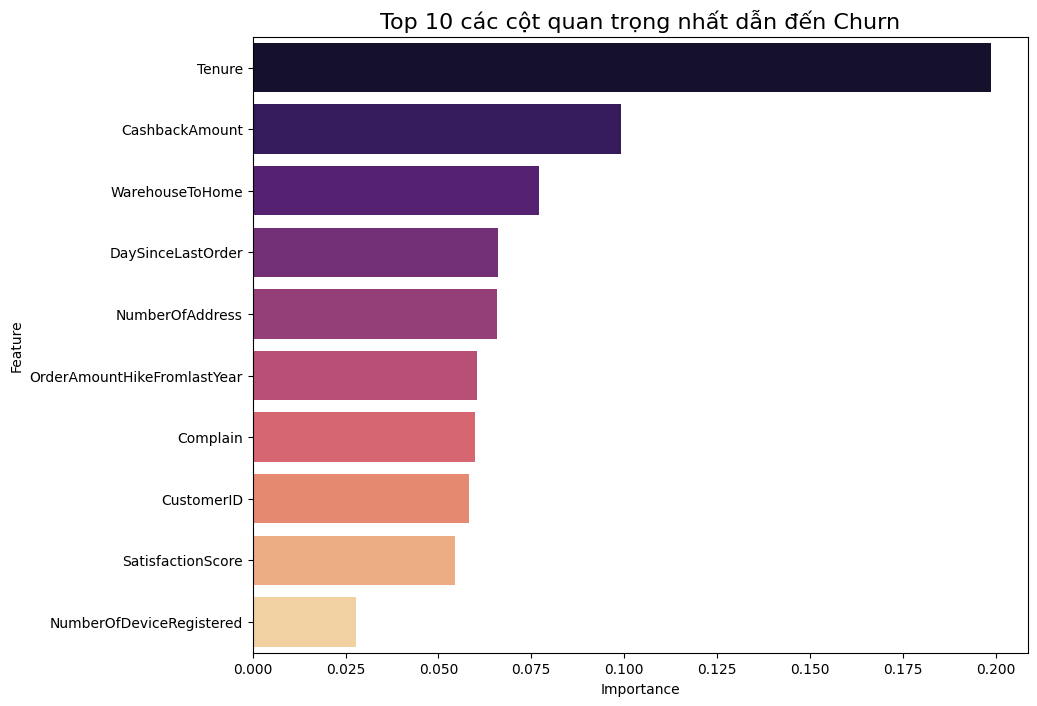

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_eda = RandomForestClassifier(random_state=42)
rf_eda.fit(X_train_scaled, y_train)

# Lấy độ quan trọng
importances = rf_eda.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 các cột quan trọng nhất dẫn đến Churn', fontsize=16)
plt.show()

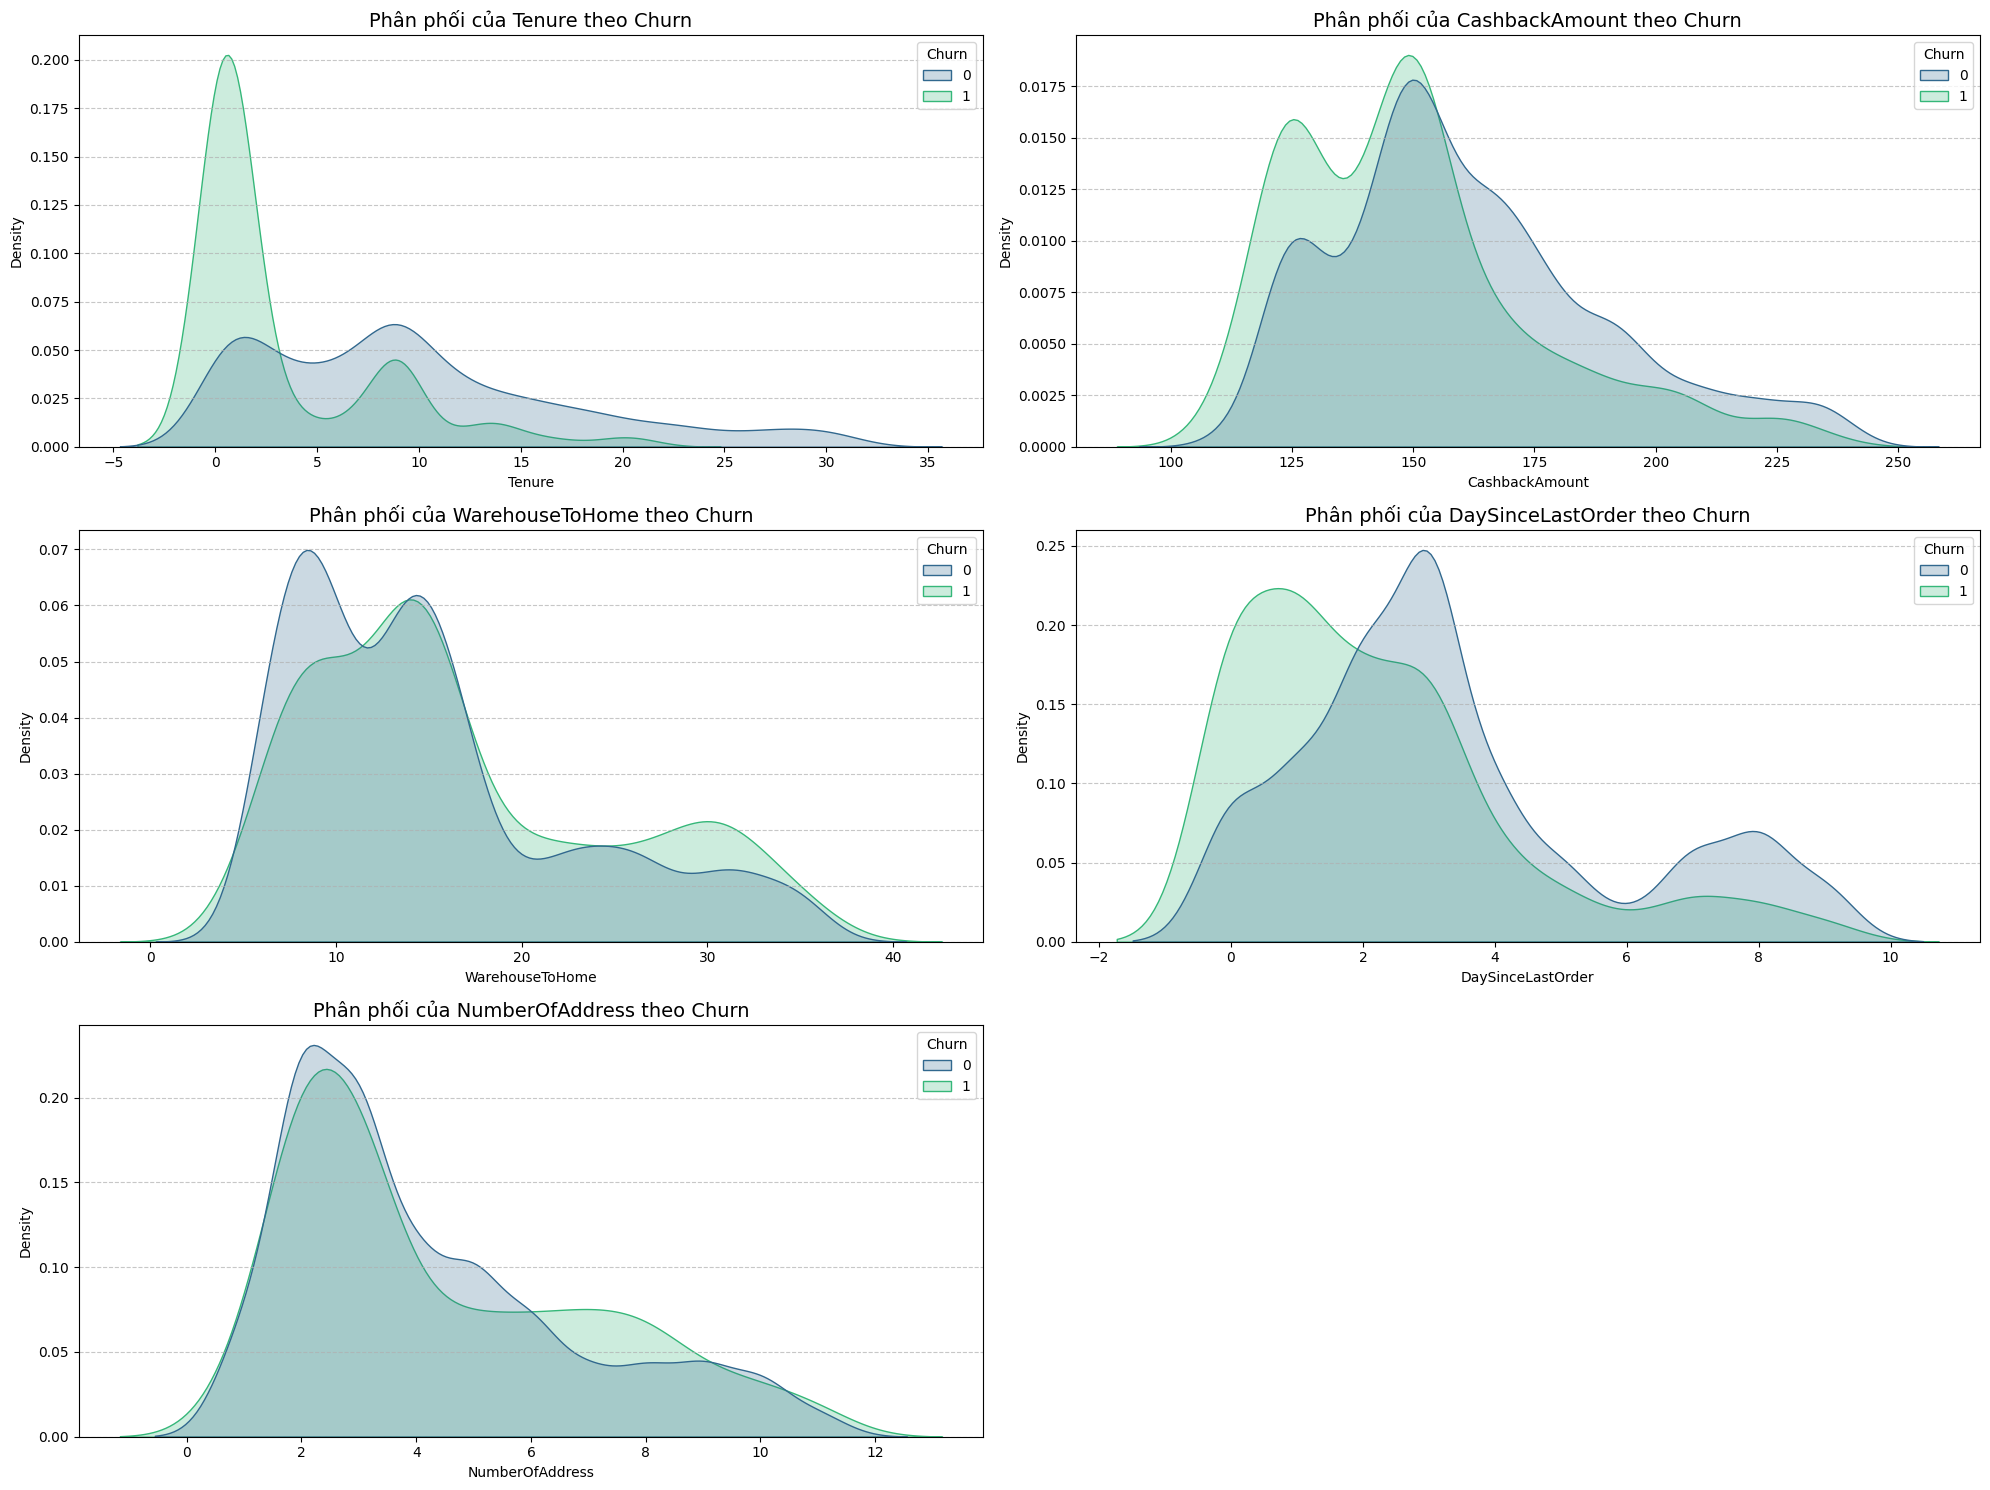

In [ ]:
top_5_features = feature_importance_df.head(5)['Feature'].tolist()
plt.figure(figsize=(20, 15))

for i, col in enumerate(top_5_features):
    plt.subplot(3, 2, i + 1)
    # Sử dụng boxplot hoặc kdeplot tùy thuộc vào bản chất dữ liệu
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, palette='viridis', common_norm=False)
    plt.title(f'Phân phối của {col} theo Churn', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

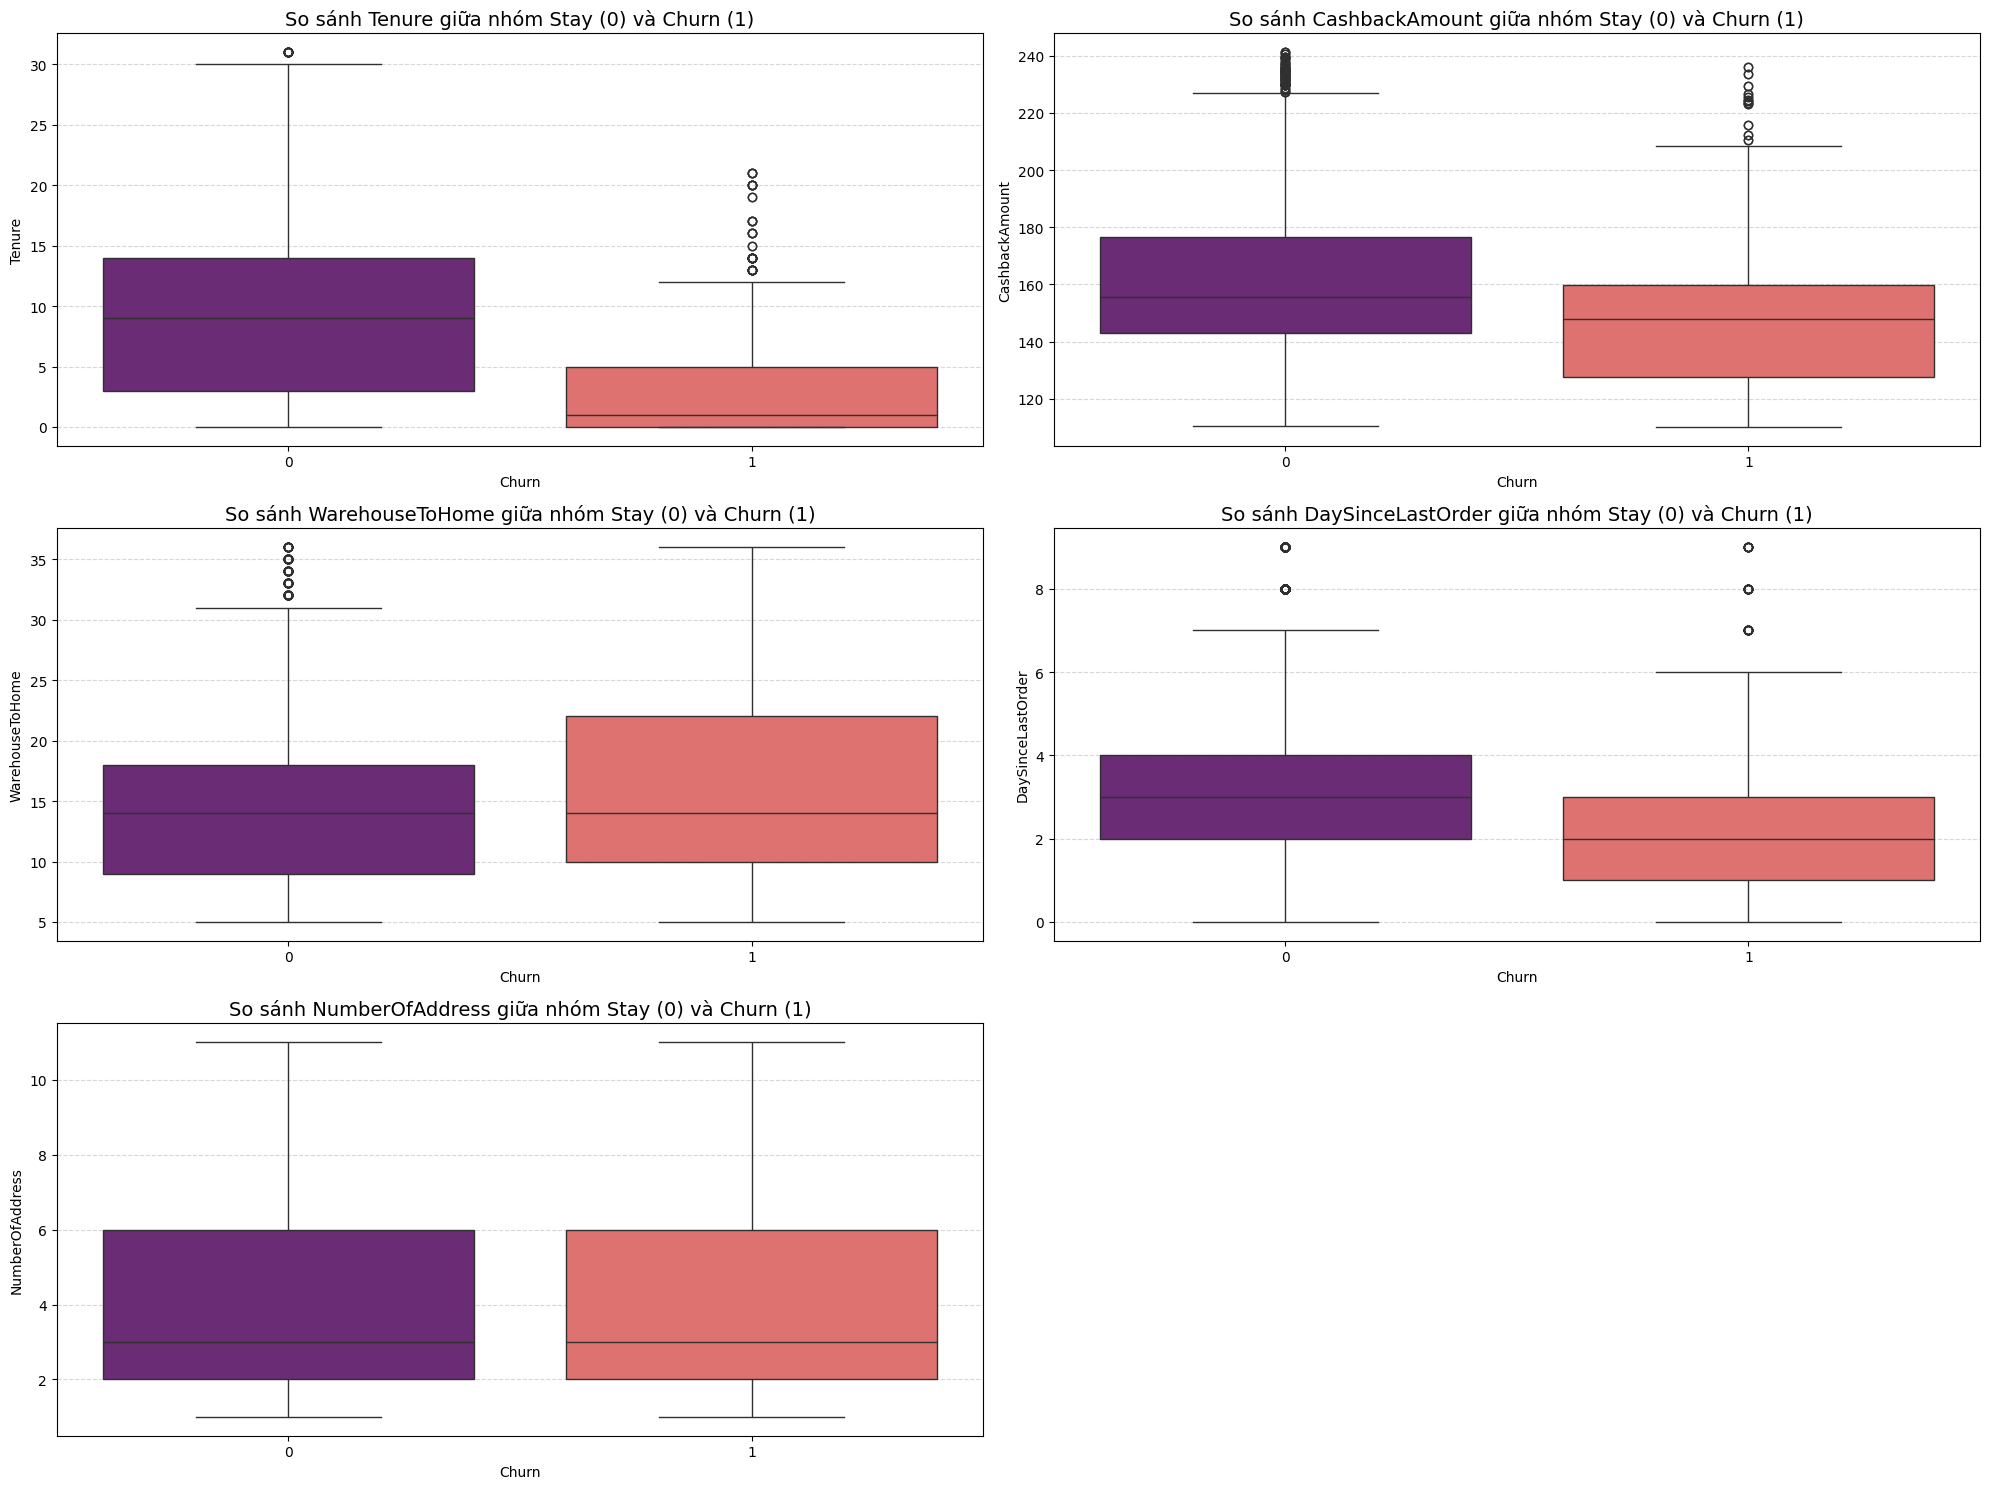

In [ ]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(top_5_features):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data=df, x='Churn', y=col, palette='magma')
    plt.title(f'So sánh {col} giữa nhóm Stay (0) và Churn (1)', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Đề xuất chiến lược giảm Churn

###Hành động cụ thể:
*   **Đối với khách hàng mới (Tenure thấp):** Triển khai chương trình onboarding tốt hơn, tặng mã giảm giá cho đơn hàng thứ 2 và thứ 3 ngay sau khi hoàn thành đơn đầu tiên.
*   **Xử lý khiếu nại (Complain):** Xây dựng quy trình bồi hoàn tự động hoặc chủ động gọi điện chăm sóc ngay khi có phản hồi tiêu cực.
*   **Duy trì tương tác (DaySinceLastOrder):** Gửi thông báo đẩy (Push Notification) hoặc Email Marketing nhắc nhớ các sản phẩm họ thường xem nếu họ không đăng nhập quá 7-10 ngày.
*   **Cải thiện Satisfaction Score:** Khảo sát nhanh lý do sau mỗi dịch vụ và tập trung cải thiện các mảng bị chấm điểm thấp (thường liên quan đến giao hàng hoặc chất lượng sản phẩm).

## 3. So sánh và Tìm kiếm Mô hình tốt nhất

Trong phần này, chúng ta sẽ thử nghiệm nhiều thuật toán khác nhau để tìm ra mô hình có khả năng dự đoán khách hàng rời bỏ chính xác nhất.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

model_dict = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []
best_models = {}

for name, model in model_dict.items():
    print(f"Đang huấn luyện {name}...")
    model.fit(X_train_scaled, y_train)
    best_models[name] = model

    y_pred = model.predict(X_val_scaled)

    results.append({
        'Model': name,
        'Balanced Accuracy': balanced_accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='Balanced Accuracy', ascending=False)
print("\n--- BẢNG SO SÁNH CHỈ SỐ TRÊN TẬP VALIDATION ---")
display(results_df)

Đang huấn luyện Logistic Regression...
Đang huấn luyện Decision Tree...
Đang huấn luyện Random Forest...
Đang huấn luyện Gradient Boosting...

--- BẢNG SO SÁNH CHỈ SỐ TRÊN TẬP VALIDATION ---


,Model,Balanced Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.860564,0.980392,0.724638,0.833333
3,Gradient Boosting,0.815561,0.882353,0.652174,0.750000
1,Decision Tree,0.776049,0.773585,0.594203,0.672131
0,Logistic Regression,0.755835,0.840909,0.536232,0.654867


### Đánh giá mô hình tốt nhất trên tập Test

Sau khi so sánh, chúng ta sẽ chọn mô hình có Balanced Accuracy cao nhất trên tập Validation để kiểm tra cuối cùng trên tập Test.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [10,50,100],
    'max_depth': [None,20]
}

print("Đang tối ưu hóa Random Forest bằng GridSearchCV...")
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid,
                              cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train_scaled, y_train)

best_rf_model = grid_search_rf.best_estimator_
print(f"Tham số tốt nhất: {grid_search_rf.best_params_}")

# Đánh giá lại trên tập Validation và Test
y_val_pred_optimized = best_rf_model.predict(X_val_scaled)
y_test_pred_optimized = best_rf_model.predict(X_test_scaled)

print("\n--- KẾT QUẢ SAU KHI TỐI ƯU HÓA ---")
print(f"Balanced Accuracy (Validation): {balanced_accuracy_score(y_val, y_val_pred_optimized):.4f}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_test_pred_optimized):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_optimized))

Đang tối ưu hóa Random Forest bằng GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tham số tốt nhất: {'max_depth': None, 'n_estimators': 100}

--- KẾT QUẢ SAU KHI TỐI ƯU HÓA ---
Balanced Accuracy (Validation): 0.8461
Balanced Accuracy (Test): 0.8841

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       286
           1       1.00      0.77      0.87        69

    accuracy                           0.95       355
   macro avg       0.97      0.88      0.92       355
weighted avg       0.96      0.95      0.95       355



## 4. Unsupervised Learning: Phân khúc khách hàng rời bỏ

Để hiểu rõ hơn hành vi của những khách hàng đã rời bỏ (churn=1), chúng ta sẽ thực hiện phân cụm (clustering) trên tập dữ liệu của những người này.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
churn_df = df_encoded[df_encoded['Churn'] == 1].copy()
churn_df = churn_df.drop(columns=['CustomerID', 'Churn'])

print(f"Kích thước tập dữ liệu khách hàng rời bỏ: {churn_df.shape}")
display(churn_df.head())

Kích thước tập dữ liệu khách hàng rời bỏ: (688, 24)


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,MaritalStatus_Married,MaritalStatus_Single
40,9.0,1,16.0,3.0,4,4,2,1,25.0,1.0,...,True,False,False,False,False,False,False,True,False,True
58,9.0,1,16.0,3.0,4,4,2,1,25.0,0.0,...,True,False,False,False,False,False,False,True,False,True
78,1.0,1,32.0,3.0,4,2,3,1,25.0,2.0,...,False,True,False,False,True,False,False,True,False,True
79,21.0,1,9.0,3.0,4,3,6,0,25.0,2.0,...,False,False,False,False,True,False,False,True,False,True
80,1.0,1,21.0,3.0,5,4,3,1,25.0,2.0,...,False,False,False,True,True,False,False,True,True,False


In [ ]:
from sklearn.preprocessing import MinMaxScaler

churn_features = churn_df.copy()
if 'CustomerID' in churn_features.columns:
    churn_features = churn_features.drop(columns=['CustomerID'])
if 'Churn' in churn_features.columns:
    churn_features = churn_features.drop(columns=['Churn'])

# Normalization
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(churn_df)
scaled_df = pd.DataFrame(scaled_data, columns=churn_df.columns)

display(scaled_df.head())

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,MaritalStatus_Married,MaritalStatus_Single
0,0.428571,0.0,0.354839,0.5,0.666667,0.75,0.1,1.0,1.0,0.333333,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.428571,0.0,0.354839,0.5,0.666667,0.75,0.1,1.0,1.0,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.047619,0.0,0.870968,0.5,0.666667,0.25,0.2,1.0,1.0,0.666667,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,1.000000,0.0,0.129032,0.5,0.666667,0.50,0.5,0.0,1.0,0.666667,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,0.047619,0.0,0.516129,0.5,1.000000,0.75,0.2,1.0,1.0,0.666667,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688 entries, 0 to 687
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Tenure                               688 non-null    float64
 1   CityTier                             688 non-null    float64
 2   WarehouseToHome                      688 non-null    float64
 3   HourSpendOnApp                       688 non-null    float64
 4   NumberOfDeviceRegistered             688 non-null    float64
 5   SatisfactionScore                    688 non-null    float64
 6   NumberOfAddress                      688 non-null    float64
 7   Complain                             688 non-null    float64
 8   OrderAmountHikeFromlastYear          688 non-null    float64
 9   CouponUsed                           688 non-null    float64
 10  OrderCount                           688 non-null    float64
 11  DaySinceLastOrder               

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
pca.fit(churn_features)
PCA_df=pd.DataFrame(pca.transform(churn_features), columns=['PC1', 'PC2', 'PC3'])
PCA_df.head()

,PC1,PC2,PC3
0,-31.312254,2.580547,5.155448
1,-31.323260,2.590839,5.173690
2,4.344812,15.616104,-2.441965
3,-0.658541,-7.619256,16.820871
4,12.853978,3.925531,-3.001386


In [ ]:
pca.explained_variance_ratio_

array([0.85692618, 0.0774411 , 0.02767301])

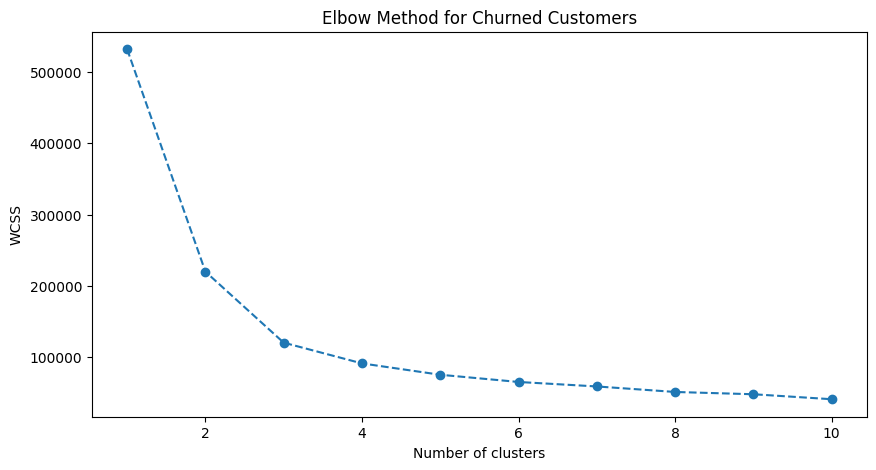

In [ ]:
ss_churn = []
max_clusters = 10
for i in range(1, max_clusters + 1):
    kmeans_churn = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans_churn.fit(PCA_df)
    ss_churn.append(kmeans_churn.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_clusters + 1), ss_churn, marker='o', linestyle='--')
plt.title('Elbow Method for Churned Customers')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans_final_churn = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
predicted_labels_churn = kmeans_final_churn.fit_predict(PCA_df)

churn_df['cluster'] = predicted_labels_churn
PCA_df['cluster'] = predicted_labels_churn

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(PCA_df, predicted_labels_churn)
print(sil_score)


0.482865855928605


In [ ]:
print("Số lượng khách hàng trong mỗi cụm:")
print(churn_df['cluster'].value_counts())
display(churn_df.head())

Số lượng khách hàng trong mỗi cụm:
cluster
2    329
0    253
1    106
Name: count, dtype: int64


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,MaritalStatus_Married,MaritalStatus_Single,cluster
40,9.0,1,16.0,3.0,4,4,2,1,25.0,1.0,...,False,False,False,False,False,False,True,False,True,0
58,9.0,1,16.0,3.0,4,4,2,1,25.0,0.0,...,False,False,False,False,False,False,True,False,True,0
78,1.0,1,32.0,3.0,4,2,3,1,25.0,2.0,...,True,False,False,True,False,False,True,False,True,2
79,21.0,1,9.0,3.0,4,3,6,0,25.0,2.0,...,False,False,False,True,False,False,True,False,True,2
80,1.0,1,21.0,3.0,5,4,3,1,25.0,2.0,...,False,False,True,True,False,False,True,True,False,2


In [ ]:
cluster_analysis = churn_df.groupby('cluster').mean()
display(cluster_analysis)

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,MaritalStatus_Married,MaritalStatus_Single
cluster,,,,,,,,,,,,,,,,,,,,,
0,3.822134,1.569170,14.561265,2.569170,3.616601,3.343874,3.355731,0.545455,15.343874,0.624506,...,0.264822,0.391304,0.094862,0.079051,0.656126,0.0,0.011858,0.988142,0.328063,0.569170
1,4.509434,2.301887,21.443396,3.226415,3.952830,3.537736,5.603774,0.566038,14.584906,1.377358,...,0.169811,0.283019,0.377358,0.037736,0.603774,0.0,0.452830,0.000000,0.424528,0.452830
2,2.355623,1.723404,16.775076,3.161094,4.082067,3.544073,4.854103,0.510638,16.063830,1.346505,...,0.310030,0.364742,0.112462,0.088146,0.665653,0.0,0.288754,0.699088,0.370821,0.492401


Balanced Accuracy trên tập Test của Random Forest cho phân cụm: 1.0000


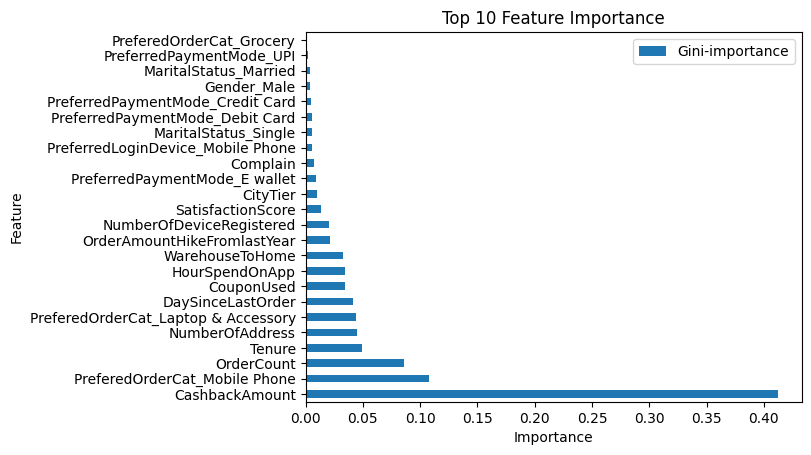

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import balanced_accuracy_score

X_cluster = churn_features.copy()
y_cluster = churn_df['cluster'].copy()

X_cluster_train, X_cluster_test, y_cluster_train, y_cluster_test = train_test_split(X_cluster, y_cluster, test_size=0.3, random_state=42, stratify=y_cluster) # Giảm test_size để có nhiều dữ liệu hơn cho huấn luyện

scaler_c = MinMaxScaler()
X_train_c_scaled = scaler_c.fit_transform(X_cluster_train)
X_test_c_scaled = scaler_c.transform(X_cluster_test)
rf_cluster = RandomForestClassifier(max_depth=15, random_state=0, n_estimators = 100)
rf_cluster.fit(X_train_c_scaled, y_cluster_train)

y_ranf_pre_test = rf_cluster.predict(X_test_c_scaled)
balanced_accuracy_test = balanced_accuracy_score(y_cluster_test, y_ranf_pre_test)

print(f"Balanced Accuracy trên tập Test của Random Forest cho phân cụm: {balanced_accuracy_test:.4f}")

feats = {} # a dict to hold feature_name: feature_importance
for feature, importance in zip(X_cluster_test.columns, rf_cluster.feature_importances_):
    feats[feature] = importance #add the name/value pair

importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Gini-importance'})
importances = importances.sort_values(by='Gini-importance', ascending=True)

importances = importances.reset_index()

importances.plot(x='index', y='Gini-importance', kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance')
plt.show()

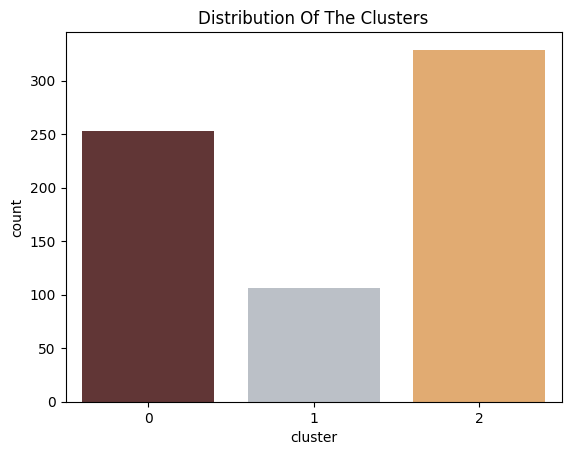

In [ ]:
pal = ["#682F2F","#B9C0C9","#F3AB60"]
pl = sns.countplot(x=churn_df["cluster"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

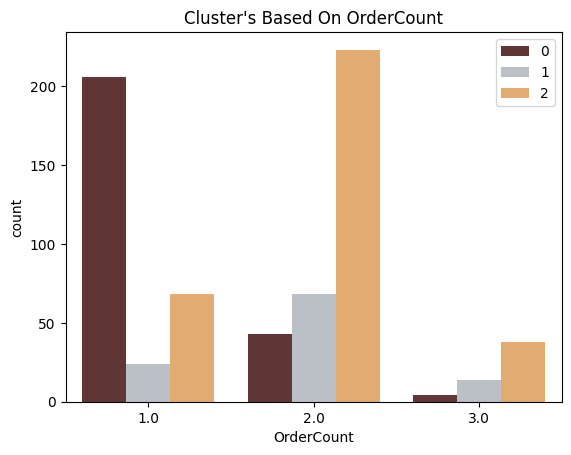

In [ ]:
pl = sns.countplot(data = churn_df, x="OrderCount", hue="cluster", palette= pal)
pl.set_title("Cluster's Based On OrderCount")
plt.legend()
plt.show()

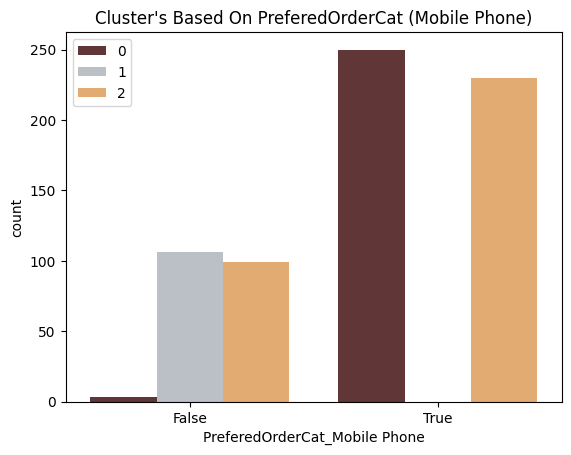

In [ ]:
pl = sns.countplot(data = churn_df, x="PreferedOrderCat_Mobile Phone", hue="cluster", palette= pal)
pl.set_title("Cluster's Based On PreferedOrderCat (Mobile Phone)")
plt.legend()
plt.show()

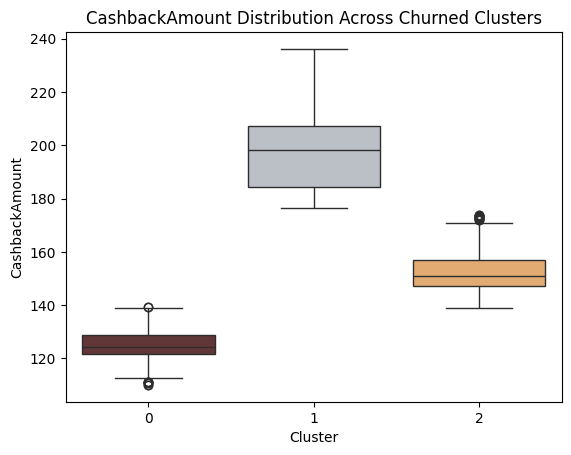

In [ ]:
sns.boxplot(data = churn_df, x="cluster", y="CashbackAmount", palette=pal)
plt.title("CashbackAmount Distribution Across Churned Clusters")
plt.xlabel("Cluster")
plt.ylabel("CashbackAmount")
plt.show()

### Phân tích sự khác biệt giữa các cụm khách hàng rời bỏ (Churn Clusters)

**Cụm 0 (Cluster 0):**
*   **CashbackAmount (Số tiền hoàn lại):** Cụm này có lượng cashback trung bình ở mức khá, cao hơn cụm 1 nhưng thấp hơn cụm 2.
*   **OrderCount (Số lượng đơn hàng):** Như quan sát trên biểu đồ, khách hàng ở cụm 0 có số lượng đơn hàng tập trung ở mức thấp đến trung bình, cho thấy họ chưa thực sự gắn kết sâu với nền tảng.
*   **PreferedOrderCat_Mobile Phone:** Thể hiện sự ưa thích mua sắm điện thoại di động rõ rệt.

**Cụm 1 (Cluster 1):**
*   **CashbackAmount:** Cụm này có lượng cashback trung bình thấp nhất. Đây có thể là lý do chính khiến họ rời đi vì thiếu động lực về ưu đãi tài chính.
*   **OrderCount:** Số lượng đơn hàng của cụm này cũng ở mức thấp, tương ứng với việc họ nhận được ít cashback.
*   **PreferedOrderCat_Mobile Phone:** Ưa thích đặt hàng điện thoại di động ở mức trung bình.

**Cụm 2 (Cluster 2):**
*   **CashbackAmount:** Có lượng cashback trung bình cao nhất. Dù nhận được nhiều ưu đãi nhất, họ vẫn rời bỏ, cho thấy nguyên nhân có thể nằm ở các yếu tố trải nghiệm khác.
*   **OrderCount:** Đây là nhóm có số lượng đơn hàng cao nhất và phân tán rộng nhất, cho thấy đây từng là nhóm khách hàng trung thành hoặc có nhu cầu mua sắm lớn.
*   **PreferedOrderCat_Mobile Phone:** Ưa thích đặt hàng điện thoại di động ở mức trung bình.

**Tóm lại:**
*   **Cụm 0:** Khách hàng mới hoặc ít tương tác, tập trung mua điện thoại, cashback trung bình.
*   **Cụm 1:** Nhóm nhận ít ưu đãi nhất và có số lượng đơn hàng thấp nhất.
*   **Cụm 2:** Nhóm khách hàng từng hoạt động tích cực nhất (OrderCount cao) và nhận nhiều cashback nhất nhưng vẫn rời bỏ hệ thống.